In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **STEP 1**

# ***[Environment Setup & Dataset Access (Professional Version)]***


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path

In [ ]:
# Project root directory
PROJECT_ROOT = Path("/content/drive/MyDrive/NEU-DET")

# Dataset paths
TRAIN_DIR = PROJECT_ROOT / "train" / "images"
VAL_DIR = PROJECT_ROOT / "validation" / "images"

print("Train Path:", TRAIN_DIR)
print("Validation Path:", VAL_DIR)

Train Path: /content/drive/MyDrive/NEU-DET/train/images
Validation Path: /content/drive/MyDrive/NEU-DET/validation/images


In [ ]:
print("Training Classes:")
print(os.listdir(TRAIN_DIR))

print("\nValidation Classes:")
print(os.listdir(VAL_DIR))

Training Classes:
['pitted_surface', 'scratches', 'rolled-in_scale', 'patches', 'inclusion', 'crazing']

Validation Classes:
['rolled-in_scale', 'patches', 'scratches', 'pitted_surface', 'inclusion', 'crazing']


In [ ]:
def count_images(folder):
    for cls in sorted(os.listdir(folder)):
        class_path = folder / cls
        if class_path.is_dir():
            print(f"{cls}: {len(os.listdir(class_path))} images")

print("\nTrain Dataset Distribution:")
count_images(TRAIN_DIR)

print("\nValidation Dataset Distribution:")
count_images(VAL_DIR)


Train Dataset Distribution:
crazing: 240 images
inclusion: 240 images
patches: 240 images
pitted_surface: 241 images
rolled-in_scale: 240 images
scratches: 240 images

Validation Dataset Distribution:
crazing: 60 images
inclusion: 60 images
patches: 60 images
pitted_surface: 60 images
rolled-in_scale: 60 images
scratches: 60 images


# **STEP 2**

#***[Professional Data Understanding & Visualization]***


In [ ]:
from PIL import Image
import random

In [ ]:
classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [ ]:
def show_random_samples(base_dir, classes, samples_per_class=2):

    plt.figure(figsize=(12,8))
    plot_index = 1

    for cls in classes:
        class_path = base_dir / cls
        images = os.listdir(class_path)

        random_images = random.sample(images, samples_per_class)

        for img_name in random_images:
            img_path = class_path / img_name
            img = Image.open(img_path)

            plt.subplot(len(classes), samples_per_class, plot_index)
            plt.imshow(img, cmap='gray')
            plt.title(cls)
            plt.axis("off")

            plot_index += 1

    plt.tight_layout()
    plt.show()

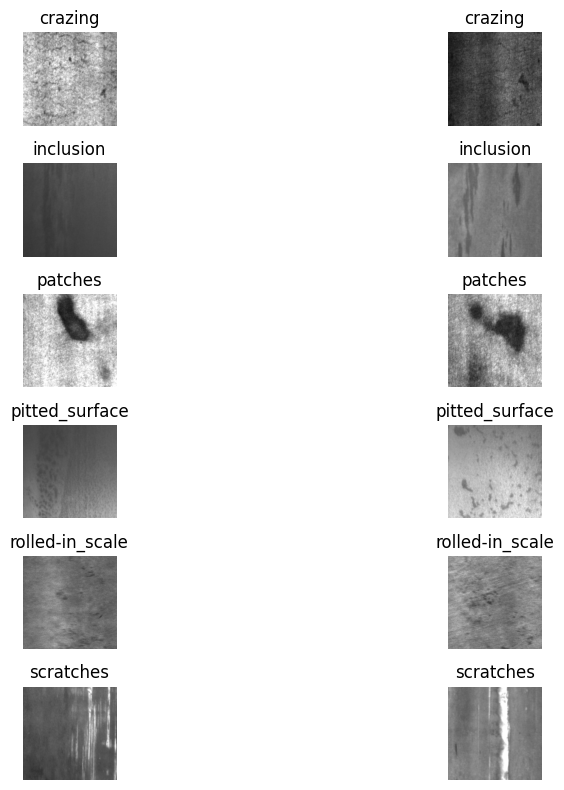

In [ ]:
show_random_samples(TRAIN_DIR, classes)

# **STEP 3**

#***[Professional Preprocessing & Augmentation Setup]***

In [ ]:
import torch
from torchvision import transforms

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# **STEP 4**

#***[Professional Dataset Loading & DataLoader Setup]***

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

In [ ]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

In [ ]:
val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transform
)

In [ ]:
print("Class Names:", train_dataset.classes)
print("Class Index Mapping:", train_dataset.class_to_idx)

Class Names: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Class Index Mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Batch shape: torch.Size([32, 1, 200, 200])
Labels shape: torch.Size([32])


# **STEP 5**

#***[Professional Baseline CNN Architecture]***

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class BaselineCNN(nn.Module):

    def __init__(self, num_classes=6):
        super(BaselineCNN, self).__init__()

        # -------- Convolution Block 1 --------
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        # -------- Convolution Block 2 --------
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        # -------- Convolution Block 3 --------
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        # -------- Fully Connected Layers --------
        self.dropout = nn.Dropout(0.5)

        # Calculate flattened size:
        # Input = 200x200
        # After pool1 -> 100x100
        # After pool2 -> 50x50
        # After pool3 -> 25x25

        self.fc1 = nn.Linear(128 * 25 * 25, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):

        # Block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))

        # Block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        # Block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
model = BaselineCNN(num_classes=6)
print(model)

BaselineCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=80000, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


# **STEP 6**

#***[Professional Training Setup]***

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
best_val_loss = float('inf')
patience = 5
patience_counter = 0

In [ ]:
num_epochs = 25

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# **STEP 7**

#***[Professional Training Loop (Industrial Standard)]***

In [ ]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ======================
    # TRAINING PHASE
    # ======================
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")

    # ======================
    # VALIDATION PHASE
    # ======================
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

    # ======================
    # EARLY STOPPING
    # ======================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "best_model.pth")

        print("Validation improved — model saved.")

    else:

        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1/25
Train Loss: 6.8047 | Train Acc: 0.5690
Val Loss: 6.0769 | Val Acc: 0.2639
Validation improved — model saved.

Epoch 2/25
Train Loss: 1.0469 | Train Acc: 0.6738
Val Loss: 1.0317 | Val Acc: 0.6306
Validation improved — model saved.

Epoch 3/25
Train Loss: 0.7672 | Train Acc: 0.6905
Val Loss: 0.9671 | Val Acc: 0.6444
Validation improved — model saved.

Epoch 4/25
Train Loss: 0.8714 | Train Acc: 0.6579
Val Loss: 0.8715 | Val Acc: 0.6667
Validation improved — model saved.

Epoch 5/25
Train Loss: 0.7140 | Train Acc: 0.7065
Val Loss: 0.6066 | Val Acc: 0.7722
Validation improved — model saved.

Epoch 6/25
Train Loss: 0.7038 | Train Acc: 0.7058
Val Loss: 1.5671 | Val Acc: 0.6250
No improvement. Patience: 1/5

Epoch 7/25
Train Loss: 0.7964 | Train Acc: 0.6669
Val Loss: 0.6954 | Val Acc: 0.7861
No improvement. Patience: 2/5

Epoch 8/25
Train Loss: 0.7576 | Train Acc: 0.6815
Val Loss: 1.0709 | Val Acc: 0.6000
No improvement. Patience: 3/5

Epoch 9/25
Train Loss: 0.6782 | Train Acc: 0.7

# **STEP 8**
#***[Professional Evaluation (Industrial Metrics)]***

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,recall_score,f1_score

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

BaselineCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=80000, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)

In [ ]:
# all_preds = []
# all_labels = []

# with torch.no_grad():

#     for images, labels in val_loader:

#         images = images.to(device)
#         labels = labels.to(device)

#         outputs = model(images)

#         _, predicted = torch.max(outputs, 1)

#         all_preds.extend(predicted.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

In [ ]:
# ======================
# TEST EVALUATION
# ======================

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7722222222222223


In [ ]:
accuracy = accuracy_score(all_labels, all_preds)
print("Accuracy:", accuracy)

Accuracy: 0.7722222222222223


In [ ]:
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))


Classification Report:

                 precision    recall  f1-score   support

        crazing       0.88      0.98      0.93        60
      inclusion       0.60      0.70      0.65        60
        patches       0.98      0.87      0.92        60
 pitted_surface       0.76      0.62      0.68        60
rolled-in_scale       1.00      0.68      0.81        60
      scratches       0.59      0.78      0.67        60

       accuracy                           0.77       360
      macro avg       0.80      0.77      0.78       360
   weighted avg       0.80      0.77      0.78       360



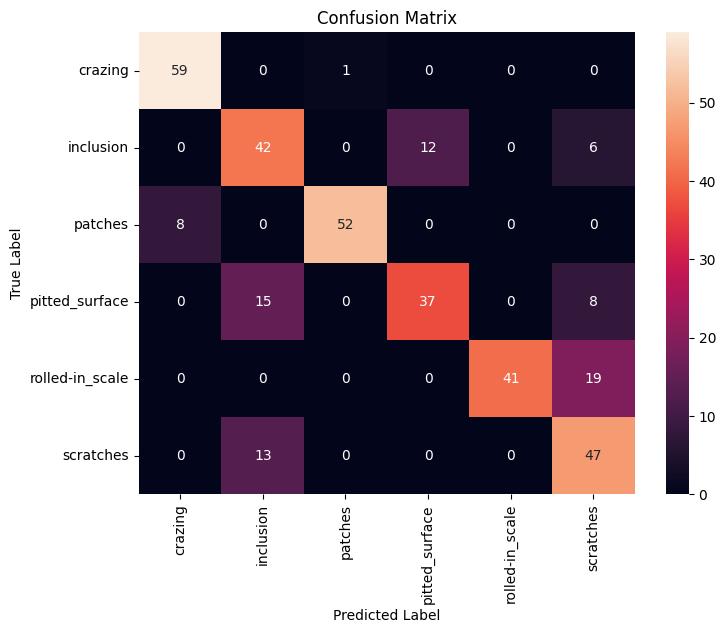

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# **STEP 9**
#***[Transfer Learning (ResNet50 Industrial Implementation)]***

In [ ]:
import torchvision.models as models

In [ ]:
resnet_model = models.resnet50(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 129MB/s]


In [ ]:
resnet_model.conv1 = nn.Conv2d(
    1,          # input channels changed from 3 → 1
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

In [ ]:
num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Linear(num_features, 6)

In [ ]:
for param in resnet_model.parameters():
    param.requires_grad = False

In [ ]:
for param in resnet_model.fc.parameters():
    param.requires_grad = True

In [ ]:
resnet_model=resnet_model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.0001
)

# **STEP 10**
#***[Training Loop for ResNet50 (Transfer Learning)]***

In [ ]:
best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

num_epochs = 15

In [ ]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ======================
    # TRAINING PHASE
    # ======================
    resnet_model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = resnet_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")

    # ======================
    # VALIDATION PHASE
    # ======================
    resnet_model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

    # ======================
    # EARLY STOPPING
    # ======================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(resnet_model.state_dict(), "best_resnet_model.pth")

        print("Validation improved — model saved.")

    else:

        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1/15
Train Loss: 1.7096 | Train Acc: 0.3539
Val Loss: 1.8036 | Val Acc: 0.1917
Validation improved — model saved.

Epoch 2/15
Train Loss: 1.5457 | Train Acc: 0.6322
Val Loss: 1.6363 | Val Acc: 0.5000
Validation improved — model saved.

Epoch 3/15
Train Loss: 1.3972 | Train Acc: 0.7759
Val Loss: 1.5223 | Val Acc: 0.6417
Validation improved — model saved.

Epoch 4/15
Train Loss: 1.2823 | Train Acc: 0.8265
Val Loss: 1.4546 | Val Acc: 0.7250
Validation improved — model saved.

Epoch 5/15
Train Loss: 1.1789 | Train Acc: 0.8439
Val Loss: 1.4166 | Val Acc: 0.7472
Validation improved — model saved.

Epoch 6/15
Train Loss: 1.1039 | Train Acc: 0.8397
Val Loss: 1.2744 | Val Acc: 0.7750
Validation improved — model saved.

Epoch 7/15
Train Loss: 1.0254 | Train Acc: 0.8681
Val Loss: 1.2809 | Val Acc: 0.7083
No improvement. Patience: 1/5

Epoch 8/15
Train Loss: 0.9595 | Train Acc: 0.8591
Val Loss: 1.1908 | Val Acc: 0.7750
Validation improved — model saved.

Epoch 9/15
Train Loss: 0.9083 | Trai

# **STEP 11**
#***[Industrial Comparison (Baseline vs Transfer Learning)]***

In [ ]:
resnet_model.load_state_dict(torch.load("best_resnet_model.pth"))
resnet_model.eval()

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
all_preds_resnet = []
all_labels_resnet = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds_resnet.extend(predicted.cpu().numpy())
        all_labels_resnet.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Transfer Learning Accuracy:",
      accuracy_score(all_labels_resnet, all_preds_resnet))

print("\nTransfer Learning Classification Report:\n")

print(classification_report(
    all_labels_resnet,
    all_preds_resnet,
    target_names=train_dataset.classes
))

Transfer Learning Accuracy: 0.8055555555555556

Transfer Learning Classification Report:

                 precision    recall  f1-score   support

        crazing       1.00      0.95      0.97        60
      inclusion       0.80      0.40      0.53        60
        patches       0.94      1.00      0.97        60
 pitted_surface       0.67      0.83      0.74        60
rolled-in_scale       0.96      0.72      0.82        60
      scratches       0.63      0.93      0.75        60

       accuracy                           0.81       360
      macro avg       0.83      0.81      0.80       360
   weighted avg       0.83      0.81      0.80       360

